In [1]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

## **DataSet**

In [2]:
class Data():
    def __init__(self, T=1000, tau=4):
        self.T = T
        self.tau = tau
        self.time = torch.arange(1, T + 1, dtype=torch.float32)
        self.x = torch.sin(0.01*self.time) + torch.randn(T)*0.2
        self.features = torch.stack([self.x[i:i + tau] for i in range(T - tau)])  # (T - tau, tau)
        self.labels = self.x[tau:].reshape(-1, 1)  # (T - tau, 1)

    def get_dataloader(self, train=True, batch_size=16, num_train=600):
        if train:
            ds = TensorDataset(self.features[:num_train], self.labels[:num_train])
            return DataLoader(ds, batch_size=batch_size, shuffle=True)
        else:
            ds = TensorDataset(self.features[num_train:], self.labels[num_train:])
            return DataLoader(ds, batch_size=batch_size, shuffle=False)

In [3]:
data = Data()

In [4]:
import matplotlib.pyplot as plt

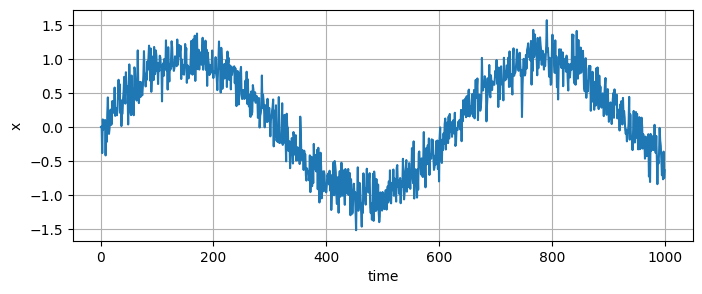

In [5]:
plt.figure(figsize=(8, 3))
plt.plot(data.time.numpy(), data.x.numpy())
plt.xlabel('time')
plt.ylabel('x')
plt.grid(True)
plt.show()

In [6]:
train_loader = data.get_dataloader(train=True)

In [7]:
val_loader = data.get_dataloader(train=False)

## **Train**

In [8]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Linear(in_features=4, out_features=1)

    def forward(self, X):
        return self.net(X)

In [9]:
model = LinearRegression()

In [10]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [11]:
num_epochs=5

In [12]:
for epoch in range(num_epochs):

    train_loss = 0
    for X, y in train_loader:
        optimizer.zero_grad()
        y_hat = model(X)
        loss = nn.functional.mse_loss(y_hat, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    with torch.no_grad():
        val_loss = 0
        for X, y in val_loader:
            y_hat = model(X)
            loss = nn.functional.mse_loss(y_hat, y)
            val_loss += loss.item()

    print(epoch, f'{train_loss/len(train_loader):.4f}', f'{val_loss/len(val_loader):.4f}')

0 0.2161 0.0780
1 0.0692 0.0618
2 0.0634 0.0603
3 0.0628 0.0596
4 0.0624 0.0589


## **Prediction**

In [13]:
y_hat = model(data.features).detach().numpy()
y = data.x[data.tau:]
x = data.time[data.tau:]

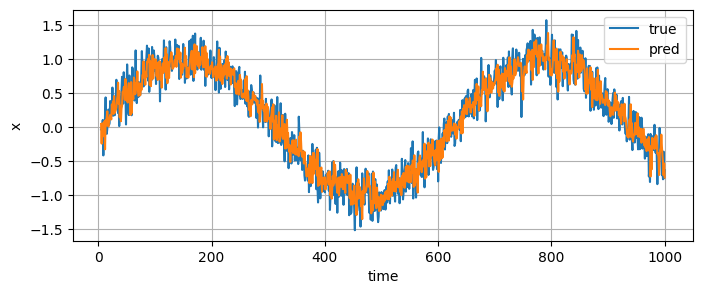

In [14]:
plt.figure(figsize=(8, 3))
plt.plot(x, y, label='true')
plt.plot(x, y_hat, label='pred')
plt.xlabel('time')
plt.ylabel('x')
plt.grid(True)
plt.legend()
plt.show()